# Housing Satisfaction Predictor (Linear Regression Model)
## API Calls
to noise, pollution, crime, housing price index, and life satisfaction (happy) datasets

In [1]:
import requests
import itertools
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

EUROSTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"

def get_stat(dataset_code):
    url = f"{EUROSTAT_BASE}/{dataset_code}"
    params = {"format": "JSON", "lang": "en"}
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()

def eurostat_to_df(data):
    dims = {
        dim: list(info["category"]["label"].values())
        for dim, info in data["dimension"].items()
    }
    keys = list(itertools.product(*dims.values()))
    values = [data["value"].get(str(i)) for i in range(len(keys))]
    df = pd.DataFrame(keys, columns=dims.keys())
    df["value"] = values
    return df

noise = get_stat("ilc_mddw04")
pollution = get_stat("ilc_mddw05")
crime = get_stat("ilc_mddw06")
hpi = get_stat("prc_hpi_a")
happy = get_stat("ilc_pw01")

df_noise = eurostat_to_df(noise)
df_pollution = eurostat_to_df(pollution)
df_crime = eurostat_to_df(crime)
df_hpi = eurostat_to_df(hpi)
df_happy = eurostat_to_df(happy)

df_noise.to_csv("noise.csv", index=False)
df_pollution.to_csv("pollution.csv", index=False)
df_crime.to_csv("crime.csv", index=False)
df_hpi.to_csv("hpi.csv", index=False)
df_happy.to_csv("happy.csv", index=False)

## Clean Datasets

In [2]:
def clean_df(df, value_col):
    """Standardise column names, drop null values, etc."""
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
    )
    df = df.rename(columns={"value": value_col})
    df = df.dropna(subset=[value_col])
    if "time" in df.columns:
        df = df.rename(columns={"time": "year"})
    df = df[df['geo'].str[0:4] != 'Euro']
    df["year"] = df["year"].astype(int)
    df[value_col] = df[value_col].astype(float)
    return df

df_noise_clean = clean_df(df_noise, "noise_rate")
df_pollution_clean = clean_df(df_pollution, "pollution_rate")
df_crime_clean = clean_df(df_crime, "crime_rate")
df_hpi_clean = clean_df(df_hpi, "hpi_weight")
df_happy_clean = clean_df(df_happy, "happy_rate")

# hpi dataset cleaning for weight column (had to do this seperately because of the 'total' purchase column)
purchase_col = [c for c in df_hpi.columns if "purch" in c]

if purchase_col:
    purchase_col = purchase_col[0]
    df_hpi_total = df_hpi[df_hpi[purchase_col].str.lower().str.contains("total")].copy()
else:
    df_hpi_total = df_hpi.copy()

df_hpi_total = df_hpi_total[df_hpi_total['unit'] == 'Annual average rate of change']
df_hpi_clean = clean_df(df_hpi_total, "hpi_weight")
df_hpi_clean.head(10)

# clean life satisfaction dataset
df_happy_clean = df_happy_clean[df_happy_clean['age'] == 'From 16 to 29 years']
df_happy_clean = df_happy_clean[df_happy_clean['sex'] == 'Total']
df_happy_clean = df_happy_clean[df_happy_clean['isced11'] == 'Tertiary education (levels 5-8)']

df_noise_clean.to_csv("noise_clean.csv", index=False)
df_pollution_clean.to_csv("pollution_clean.csv", index=False)
df_crime_clean.to_csv("crime_clean.csv", index=False)
df_hpi_clean.to_csv("hpi_clean.csv", index=False)
df_happy_clean.to_csv("happy_clean.csv", index=False)

In [3]:
# merging on common columns without aggregating
df_crime_clean = df_crime_clean.drop(columns=["freq", "unit"])
df_noise_clean = df_noise_clean.drop(columns=["freq", "unit"])
df_pollution_clean = df_pollution_clean.drop(columns=["freq", "unit"])
df_hpi_clean = df_hpi_clean.drop(columns=["freq", "purchase", "unit"])
df_happy_clean = df_happy_clean.drop(columns=["freq", "statinfo", "unit", "isced11", "life_sat"])

df_merged = df_crime_clean.merge(df_noise_clean, on=["deg_urb", "rskpovth", "geo", "year"])
df_merged = df_merged.merge(df_pollution_clean, on=["deg_urb", "rskpovth", "geo", "year"])
df_merged = df_merged.merge(df_hpi_clean, on=["geo", "year"])
df_merged = df_merged.merge(df_happy_clean, on=["geo", "year"])

df_merged = df_merged.drop(columns=["sex", 'age'])
df_merged.to_csv("merged2.csv", index=False)

### Feature Engineering

In [4]:
df = pd.read_csv("merged2.csv")
df = pd.get_dummies(df, columns=["deg_urb", "rskpovth"], drop_first=True)
df_model = (
    df.groupby(['geo', 'year'], as_index=False)
    [['crime_rate', 'noise_rate', 'pollution_rate', 'hpi_weight', 'happy_rate']].mean()
)

df['crime_noise'] = df['crime_rate'] * df['noise_rate']
df['poll_noise'] = df['pollution_rate'] * df['noise_rate']
df['crime_hpi'] = df['crime_rate'] * df['hpi_weight']
df['poll_crime'] = df['pollution_rate'] * df['crime_rate']

df.to_csv("merged2.csv", index=False)

## Data Visualizations

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load and prep data
df_noise     = pd.read_csv('noise.csv')
df_pollution = pd.read_csv('pollution.csv')
df_crime     = pd.read_csv('crime.csv')
df_hpi       = pd.read_csv('hpi.csv')
df_happy     = pd.read_csv('happy.csv')

for d in [df_noise, df_pollution, df_crime, df_hpi, df_happy]:
    d.rename(columns={'time': 'year'}, inplace=True)
    d.drop(d[d['geo'].str[0:4] == 'Euro'].index, inplace=True)
    d.dropna(subset=['value'], inplace=True)
    d['year'] = d['year'].astype(int)
    d['value'] = d['value'].astype(float)

# filter happy to 16-29, total sex, tertiary education
df_happy = df_happy[df_happy['age']     == 'From 16 to 29 years']
df_happy = df_happy[df_happy['sex']     == 'Total']
df_happy = df_happy[df_happy['isced11'] == 'Tertiary education (levels 5-8)']

# hpi — total purchase type, annual rate of change
if 'purchase' in df_hpi.columns:
    df_hpi = df_hpi[df_hpi['purchase'].str.lower().str.contains('total', na=False)].copy()
if 'unit' in df_hpi.columns:
    df_hpi = df_hpi[df_hpi['unit'] == 'Annual average rate of change'].copy()

# get urbanisation column name
urb_col = [c for c in df_crime.columns if 'urb' in c.lower() or 'degurba' in c.lower()]
urb_col = urb_col[0] if urb_col else None

# ── Build country-level summary (latest year, averaged across tiers) ──────────

def latest_mean(df, col_name):
    return (
        df.sort_values('year', ascending=False)
        .groupby('geo', as_index=False)['value']
        .first()
        .rename(columns={'value': col_name})
    )

df_c = latest_mean(df_crime,     'crime_rate')
df_n = latest_mean(df_noise,     'noise_rate')
df_p = latest_mean(df_pollution, 'pollution_rate')
df_h = latest_mean(df_hpi,       'hpi_weight')
df_s = latest_mean(df_happy,     'happy_rate')

df_country = (
    df_c
    .merge(df_n, on='geo')
    .merge(df_p, on='geo')
    .merge(df_h, on='geo')
    .merge(df_s, on='geo')
    .dropna()
)

In [6]:
# plot 1: Scatter matrix
fig1 = px.scatter_matrix(
    df_country,
    dimensions=['crime_rate', 'noise_rate', 'pollution_rate', 'hpi_weight', 'happy_rate'],
    color='happy_rate',
    color_continuous_scale='RdYlGn',
    labels={
        'crime_rate':     'Crime',
        'noise_rate':     'Noise',
        'pollution_rate': 'Pollution',
        'hpi_weight':     'HPI',
        'happy_rate':     'Satisfaction',
    },
    title='Scatter matrix — pairwise relationships between all features',
    hover_name='geo',
)
fig1.update_traces(marker=dict(size=5, opacity=0.7))
fig1.show()
#fig1.write_html('scatter_matrix.html', full_html=False, include_plotlyjs='cdn')

In [7]:
# plot 2: Crime vs satisfaction scatter by country
fig2 = px.scatter(
    df_country,
    x='crime_rate', y='happy_rate',
    text='geo',
    trendline='ols',
    title='Crime rate vs. life satisfaction by country',
    labels={'crime_rate': 'Crime rate (%)', 'happy_rate': 'Life satisfaction (0–10)', 'geo': 'Country'},
    color='happy_rate',
    color_continuous_scale='RdYlGn',
    hover_name='geo',
)
fig2.update_traces(textposition='top center', marker=dict(size=8))
fig2.show()
#fig2.write_html('crime_vs_satisfaction.html', full_html=False, include_plotlyjs='cdn')

In [8]:
# plot 3: Correlation heatmap
corr = df_country[['crime_rate', 'noise_rate', 'pollution_rate', 'hpi_weight', 'happy_rate']].corr()
labels = ['Crime', 'Noise', 'Pollution', 'HPI', 'Satisfaction']

fig3 = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=labels,
    y=labels,
    colorscale='RdYlGn',
    zmid=0,
    text=np.round(corr.values, 2),
    texttemplate='%{text}',
    hovertemplate='%{x} vs %{y}: %{z:.2f}<extra></extra>',
))
fig3.update_layout(title='Correlation heatmap — housing features vs. life satisfaction')
fig3.show()
#fig3.write_html('correlation_heatmap.html', full_html=False, include_plotlyjs='cdn')

In [9]:
# plot 4: Grouped bar — top 5 vs bottom 5 by satisfaction
top5    = df_country.nlargest(5,  'happy_rate')['geo'].tolist()
bottom5 = df_country.nsmallest(5, 'happy_rate')['geo'].tolist()
selected = df_country[df_country['geo'].isin(top5 + bottom5)].copy()
selected['group'] = selected['geo'].apply(
    lambda g: 'Top 5 happiest' if g in top5 else 'Bottom 5 happiest'
)

df_melted = selected.melt(
    id_vars=['geo', 'group'],
    value_vars=['crime_rate', 'noise_rate', 'pollution_rate'],
    var_name='indicator', value_name='rate'
)
df_melted['indicator'] = df_melted['indicator'].map({
    'crime_rate':     'Crime',
    'noise_rate':     'Noise',
    'pollution_rate': 'Pollution',
})

fig4 = px.bar(
    df_melted,
    x='geo', y='rate', color='indicator', barmode='group',
    facet_col='group', facet_col_spacing=0.08,
    title='Environmental conditions — top 5 vs bottom 5 countries by satisfaction',
    labels={'rate': 'Rate (%)', 'geo': 'Country', 'indicator': 'Indicator'},
    color_discrete_map={'Crime': '#D85A30', 'Noise': '#378ADD', 'Pollution': '#1D9E75'},
)
fig4.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig4.show()
#fig4.write_html('top_bottom_comparison.html', full_html=False, include_plotlyjs='cdn')

In [10]:
# plot 5: Choropleth map of satisfaction scores
# map country names to ISO alpha-3 codes for plotly choropleth
country_iso = {
    'Belgium': 'BEL', 'Bulgaria': 'BGR', 'Czechia': 'CZE', 'Denmark': 'DNK',
    'Germany': 'DEU', 'Estonia': 'EST', 'Ireland': 'IRL', 'Greece': 'GRC',
    'Spain': 'ESP', 'France': 'FRA', 'Croatia': 'HRV', 'Italy': 'ITA',
    'Cyprus': 'CYP', 'Latvia': 'LVA', 'Lithuania': 'LTU', 'Luxembourg': 'LUX',
    'Hungary': 'HUN', 'Malta': 'MLT', 'Netherlands': 'NLD', 'Austria': 'AUT',
    'Poland': 'POL', 'Portugal': 'PRT', 'Romania': 'ROU', 'Slovenia': 'SVN',
    'Slovakia': 'SVK', 'Finland': 'FIN', 'Sweden': 'SWE', 'Iceland': 'ISL',
    'Norway': 'NOR', 'Switzerland': 'CHE', 'Serbia': 'SRB', 'Türkiye': 'TUR',
    'North Macedonia': 'MKD', 'Montenegro': 'MNE', 'Albania': 'ALB',
    'Kosovo*': 'XKX',
}

df_map = df_country.copy()
df_map['iso'] = df_map['geo'].map(country_iso)
df_map = df_map.dropna(subset=['iso'])

fig5 = px.choropleth(
    df_map,
    locations='iso',
    color='happy_rate',
    hover_name='geo',
    hover_data={'crime_rate': ':.1f', 'noise_rate': ':.1f', 'pollution_rate': ':.1f', 'iso': False},
    color_continuous_scale='RdYlGn',
    scope='europe',
    title='Life satisfaction score across Europe — ages 16–29, tertiary education',
    labels={'happy_rate': 'Satisfaction (0–10)'},
)
fig5.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig5.show()
#fig5.write_html('choropleth_satisfaction.html', full_html=False, include_plotlyjs='cdn')

In [11]:
# plot 6: Violin — satisfaction by urbanisation tier
if urb_col:
    # merge urb tier onto happy via crime (shares deg_urb)
    df_crime_urb = (
        df_crime[['geo', 'year', urb_col, 'value']]
        .rename(columns={'value': 'crime_rate'})
    )
    df_happy_urb = (
        df_happy[['geo', 'year', 'value']]
        .rename(columns={'value': 'happy_rate'})
    )
    df_violin = df_crime_urb.merge(df_happy_urb, on=['geo', 'year'])

    fig6 = px.violin(
        df_violin,
        x=urb_col, y='happy_rate',
        box=True, points='all',
        color=urb_col,
        title='Life satisfaction by degree of urbanisation',
        labels={'happy_rate': 'Life satisfaction (0–10)', urb_col: 'Urbanisation tier'},
        hover_name='geo',
    )
fig6.show()
#fig6.write_html('satisfaction_by_urbanisation.html', full_html=False, include_plotlyjs='cdn')

In [12]:
# plot 7: HPI vs satisfaction over time by country
df_hpi_yearly = (
    df_hpi.groupby(['geo', 'year'], as_index=False)['value']
    .mean()
    .rename(columns={'value': 'hpi_weight'})
)
df_happy_yearly = (
    df_happy.groupby(['geo', 'year'], as_index=False)['value']
    .mean()
    .rename(columns={'value': 'happy_rate'})
)
df_time = df_hpi_yearly.merge(df_happy_yearly, on=['geo', 'year']).dropna()

fig7 = px.scatter(
    df_time,
    x='hpi_weight', y='happy_rate',
    animation_frame='year',
    animation_group='geo',
    color='geo',
    hover_name='geo',
    size_max=10,
    title='Housing price growth vs. life satisfaction over time',
    labels={
        'hpi_weight':  'HPI annual % change',
        'happy_rate':  'Life satisfaction (0–10)',
        'year':        'Year',
    },
)
fig7.update_layout(showlegend=False)
fig7.show()
#fig7.write_html('hpi_vs_satisfaction_time.html', full_html=False, include_plotlyjs='cdn')

## Linear Regression Model

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# linreg functions
def add_bias_column(X):
    """
    Args:
        X (array): can be either 1-d or 2-d
    
    Returns:
        Xnew (array): the same array, but 2-d with a column of 1's in the first spot
    """
    # If the array is 1-d
    if len(X.shape) == 1:
        Xnew = np.column_stack([np.ones(X.shape[0]), X])
    
    # If the array is 2-d
    elif len(X.shape) == 2:
        bias_col = np.ones((X.shape[0], 1))
        Xnew = np.hstack([bias_col, X])
        
    else:
        raise ValueError("Input array must be either 1-d or 2-d")

    return Xnew

def line_of_best_fit(X, y):
    """
    Args: 
        X (array): either 1-d or 2-d
        y (array): 1-d

    Returns:
        b (array): vector containing coefficients for line of best fit including intercept
    """
    X_bias = add_bias_column(X)
    b = np.linalg.inv(X_bias.T @ X_bias) @ (X_bias.T @ y)
    return b

def linreg_predict(Xnew, ynew, b):
    """
    Args: 
        Xnew (array either 1-d or 2-d): includes all the $p$ predictor features, not including bias term
        ynew (1-d array) includes all corresponding response values to Xnew
        b (1-d array of length $p+1$): contains the coefficients from the `line_of_best_fit` function

    Returns:
        pred (dict): 4 key value pairs- ypreds (predicted values), resids (residuals/diffs), mse, r2
    """
    X_bias = add_bias_column(Xnew)
    ypreds = X_bias @ b
    resids = ypreds - ynew
    mse = np.mean(resids ** 2)
    r2 = r2_score(ynew, ypreds)
    preds = {'ypreds': ypreds, 'resids': resids, 'mse': mse, 'r2': r2}
    return preds

cols = [
    'crime_rate', 'noise_rate', 'pollution_rate', 'hpi_weight',
    'deg_urb_Rural areas', 'deg_urb_Towns and suburbs', 'crime_noise', 'poll_noise', 'crime_hpi', 'poll_crime'
]

X = np.array(df[cols])
y = np.array(df['happy_rate'])

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled  = scaler.transform(Xtest)
 
b = line_of_best_fit(Xtrain_scaled, ytrain)
results = linreg_predict(Xtest_scaled, ytest, b)

# success metrics
print("mse:", results['mse'])
print("r2: ", results['r2'])

mse: 0.14444536654024165
r2:  0.31743650704053017


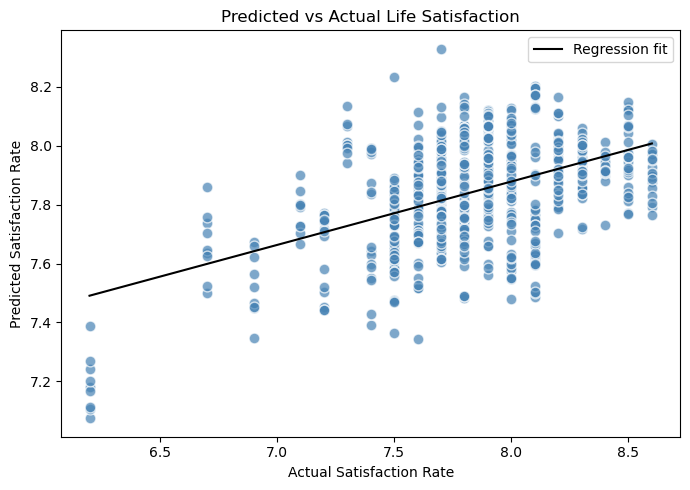

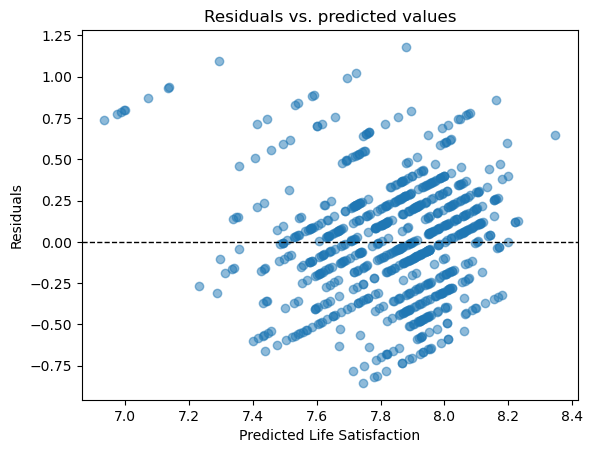

In [14]:
# get predictions on the full dataset
X_full = np.array(df[cols]).astype(float)
X_full_scaled = scaler.transform(X_full)
full_results = linreg_predict(X_full_scaled, y, b)
ypreds = full_results['ypreds']

# plot
plt.figure(figsize=(7, 5))
plt.scatter(y, ypreds, color='steelblue', edgecolors='white', s=60, alpha=0.7)

# best fit line through the scatter
m, c = np.polyfit(y, ypreds, 1)
x_line = np.linspace(y.min(), y.max(), 100)
plt.plot(x_line, m * x_line + c,
         color='black', linewidth=1.5, label='Regression fit')

plt.xlabel("Actual Satisfaction Rate")
plt.ylabel("Predicted Satisfaction Rate")
plt.title("Predicted vs Actual Life Satisfaction")
plt.legend()
plt.tight_layout()
plt.show()

# get residuals from full dataset
X_full = np.array(df[cols]).astype(float)
y      = np.array(df['happy_rate'])

# fit b on full scaled data for assumption checks
X_full_scaled = scaler.transform(X_full)
b_full = line_of_best_fit(X_full_scaled, y)
full_results = linreg_predict(X_full_scaled, y, b_full)
 
ypreds = full_results['ypreds']
resids = full_results['resids']
 
# residuals vs fitted values (checks linearity and homoscedasticity)
plt.scatter(ypreds, resids, alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted Life Satisfaction')
plt.ylabel('Residuals')
plt.title('Residuals vs. predicted values')
plt.show()

In [15]:
def predict_satisfaction(crime, noise, pollution, hpi, is_rural, is_towns, b, scaler, feature_cols, df):
    """
    Args:
        crime (float): crime rate input
        noise (float): noise rate input
        pollution (float): pollution rate input
        hpi (float): housing price index input
        is_rural (bool): True if rural area
        is_towns (bool): True if towns/suburbs (both False = cities)
        b (array): coefficients from line_of_best_fit
        scaler (StandardScaler): fitted scaler
        feature_cols (list): feature column names used in model
        df (DataFrame): needed to compute geo_mean_happy and polynomial terms

    Returns:
        predicted satisfaction score (float)
    """

    # build input row in the same column order as feature_cols
    input_dict = {
        'crime_rate':                  crime,
        'noise_rate':                  noise,
        'pollution_rate':              pollution,
        'hpi_weight':                  hpi,
        'deg_urb_Rural areas':         is_rural,
        'deg_urb_Towns and suburbs':   is_towns,
    }

    # interaction terms (must match the ones the model was trained on)
    input_dict['crime_noise'] = crime * noise
    input_dict['poll_noise']  = pollution * noise
    input_dict['crime_hpi']   = crime * hpi
    input_dict['poll_crime']  = pollution * crime

    X_input = np.array([input_dict[col] for col in feature_cols]).astype(float).reshape(1, -1)
    X_scaled = scaler.transform(X_input)
    X_bias = add_bias_column(X_scaled)
    prediction = (X_bias @ b)[0]

    print(f"Predicted life satisfaction score: {prediction:.2f}")
    return prediction

# example
predict_satisfaction(
    crime=20, noise=25, pollution=15, hpi=3.0,
    is_rural=False, is_towns=False,
    b=b, scaler=scaler, feature_cols=cols, df=df
)

Predicted life satisfaction score: 7.81


np.float64(7.811239293900467)